In [2]:
import pandas as pd

# Load the filtered expression matrix (matching clinical samples)
expr_path = r"C:\Users\Neg\RNA_seq_python_GC\expression_matched.csv"
expr_df = pd.read_csv(expr_path, index_col=0)

# Show shape and preview
print("Expression matrix shape:", expr_df.shape)
expr_df.iloc[:5, :5]  # show first 5 genes and 5 samples


Expression matrix shape: (56678, 448)


,TCGA-D7-A4YY-01,TCGA-HU-A4GH-11,TCGA-D7-8572-01,TCGA-HU-A4GQ-01,TCGA-CG-5718-01
Ensembl_ID,,,,,
ENSG00000000003.15,10.271463,9.689998,10.821774,10.852530,9.941048
ENSG00000000005.6,0.000000,5.882643,2.000000,0.000000,0.000000
ENSG00000000419.13,11.496854,10.562242,11.535761,11.647009,11.055960
ENSG00000000457.14,10.851749,9.372865,9.955650,9.353147,9.447083
ENSG00000000460.17,9.326429,7.238405,9.784635,8.854868,8.909893


In [3]:
# Extract sample types from TCGA barcodes
sample_types = expr_df.columns.str.slice(13, 15)

# Create a group label Series
sample_labels = sample_types.map({'01': 'Tumor', '11': 'Normal'})

# Show value counts
print("Sample group counts:")
print(sample_labels.value_counts())


Sample group counts:
Tumor     412
Normal     36
Name: count, dtype: int64


In [4]:
# Load clinical and expression files
clinical = pd.read_csv(r"C:\Users\Neg\RNA_seq_python_GC\clinical_cleaned.csv")
expr = pd.read_csv(r"C:\Users\Neg\RNA_seq_python_GC\filtered_counts.csv", index_col=0)

# Keep original column names for matching
common_ids = list(set(clinical['sample_id']) & set(expr.columns))

# Subset both datasets
expr_matched = expr[common_ids].copy()
clinical_matched = clinical[clinical['sample_id'].isin(common_ids)].copy()

# Now standardize sample barcodes in expr_matched
expr_matched.columns = expr_matched.columns.str.slice(0, 15)

# Save the matched files
expr_matched.to_csv(r"C:\Users\Neg\RNA_seq_python_GC\expression_matched.csv")
clinical_matched.to_csv(r"C:\Users\Neg\RNA_seq_python_GC\clinical_matched.csv", index=False)

print("✅ Fixed and saved matched expression and clinical files.")


✅ Fixed and saved matched expression and clinical files.


In [5]:
import pandas as pd

# Load the matched expression data
expr_df = pd.read_csv(r"C:\Users\Neg\RNA_seq_python_GC\expression_matched.csv", index_col=0)

# Preview shape and column names
print("Expression matrix shape:", expr_df.shape)
expr_df.iloc[:5, :5]  # first 5 genes x 5 samples


Expression matrix shape: (56678, 448)


,TCGA-BR-8077-01,TCGA-BR-8382-01,TCGA-CG-5716-01,TCGA-IN-A7NR-01,TCGA-IN-7806-01
Ensembl_ID,,,,,
ENSG00000000003.15,13.200439,6.584963,9.612868,10.390169,10.959278
ENSG00000000005.6,0.000000,2.807355,2.000000,0.000000,0.000000
ENSG00000000419.13,12.038919,9.738092,10.619303,9.350939,11.514221
ENSG00000000457.14,9.552669,8.044394,9.236014,8.011227,10.567956
ENSG00000000460.17,8.758223,7.483816,8.326429,6.894818,8.965784


In [6]:
# Extract sample type from barcode (13–15 characters)
sample_types = expr_df.columns.str.slice(13, 15)

# Create tumor/normal group labels
sample_labels = sample_types.map({'01': 'Tumor', '11': 'Normal'})

# Check distribution
print("Sample group counts:")
print(sample_labels.value_counts())


Sample group counts:
Tumor     412
Normal     36
Name: count, dtype: int64


In [7]:
from IPython.display import display
import ipywidgets as widgets
import pandas as pd
import io

# Create a file upload widget
upload_widget = widgets.FileUpload(
    accept='.csv',  # Accept only CSV files
    multiple=True   # Allow multiple file uploads
)

display(upload_widget)

# Function to process the uploaded files
def handle_upload(change):
    for filename, fileinfo in upload_widget.value.items():
        with open(filename, 'wb') as f:
            f.write(fileinfo['content'])
        print(f"✅ File saved: {filename}")

upload_widget.observe(handle_upload, names='value')


FileUpload(value={}, accept='.csv', description='Upload', multiple=True)

In [8]:
# Convert to Series explicitly
sample_labels = pd.Series(sample_labels, index=expr_df.columns)

# Save to CSV
sample_labels.to_csv(r'C:\Users\Neg\RNA_seq_python_GC\sample_labels.csv')

# Check result
print("✅ Sample labels saved.")
print(sample_labels.value_counts())


✅ Sample labels saved.
Tumor     412
Normal     36
Name: count, dtype: int64


In [9]:
expr_df = pd.read_csv(r'C:\Users\Neg\RNA_seq_python_GC\expression_matched.csv', index_col=0)
sample_labels = pd.read_csv(r'C:\Users\Neg\RNA_seq_python_GC\sample_labels.csv', index_col=0).squeeze()


In [10]:
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

# Load files from unified project path
data_path = r"C:\Users\Neg\TCGA_GC_project"
expr_df = pd.read_csv(f"{data_path}\\expression_matched.csv", index_col=0)
sample_labels = pd.read_csv(f"{data_path}\\sample_labels.csv", index_col=0).squeeze()

# Separate tumor and normal samples
tumor_samples = sample_labels[sample_labels == "Tumor"].index
normal_samples = sample_labels[sample_labels == "Normal"].index

# Initialize lists
p_values = []
log2fc_list = []

# Loop through genes
for gene in expr_df.index:
    tumor_expr = expr_df.loc[gene, tumor_samples]
    normal_expr = expr_df.loc[gene, normal_samples]
    
    # Mann-Whitney U test
    stat, p = mannwhitneyu(tumor_expr, normal_expr, alternative='two-sided')
    p_values.append(p)

    # Calculate log2 fold change
    log2fc = np.log2(tumor_expr.mean() / normal_expr.mean())
    log2fc_list.append(log2fc)

# FDR correction
fdr_results = multipletests(p_values, alpha=0.05, method='fdr_bh')
fdr = fdr_results[1]

# Compile results
deg_df = pd.DataFrame({
    "Gene": expr_df.index,
    "log2FC": log2fc_list,
    "p_value": p_values,
    "FDR": fdr
}).set_index("Gene")

# Filter DEGs
deg_filtered = deg_df[(abs(deg_df["log2FC"]) >= 1) & (deg_df["FDR"] <= 0.05)]
deg_filtered.to_csv(f"{data_path}\\DEGs_MWU_filtered.csv")

print(f"✅ DEGs saved to: {data_path}\\DEGs_MWU_filtered.csv")
print(f"Total significant DEGs: {deg_filtered.shape[0]}")
deg_filtered.head()


C:\Users\Neg\AppData\Local\Temp\ipykernel_27136\1541322213.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  log2fc = np.log2(tumor_expr.mean() / normal_expr.mean())


✅ DEGs saved to: C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv
Total significant DEGs: 9896


,log2FC,p_value,FDR
Gene,,,
ENSG00000004809.14,1.072646,3.311941e-07,2.164601e-06
ENSG00000005073.6,2.233621,6.827522e-17,1.144883e-14
ENSG00000006116.4,1.770723,1.614880e-03,4.077160e-03
ENSG00000008197.5,1.253846,8.209110e-03,1.677577e-02
ENSG00000009709.12,1.216336,3.656646e-03,8.316002e-03


In [11]:
import os

folder = r"C:\Users\Neg\TCGA_GC_project"
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]
print("CSV files in the folder:")
for f in csv_files:
    print("-", f)


CSV files in the folder:
- Avg_Tumor_Normal_Expression.csv
- clinical_cleaned.csv
- clinical_matched.csv
- DEGs_MWU_filtered.csv
- DEGs_MWU_filtered_log2fc.csv
- expression_matched.csv
- filtered_counts.csv
- log2_normalized_counts.csv
- raw_counts_backup.csv
- sample_labels.csv
- Top200_DEGs_by_absLog2FC.csv
- Top200_DEGs_for_STRING.csv
- Top200_HighConfidence_DEGs.csv
- top_DEGs_expression_check.csv


✅ Upregulated genes: 9592
✅ Downregulated genes: 304


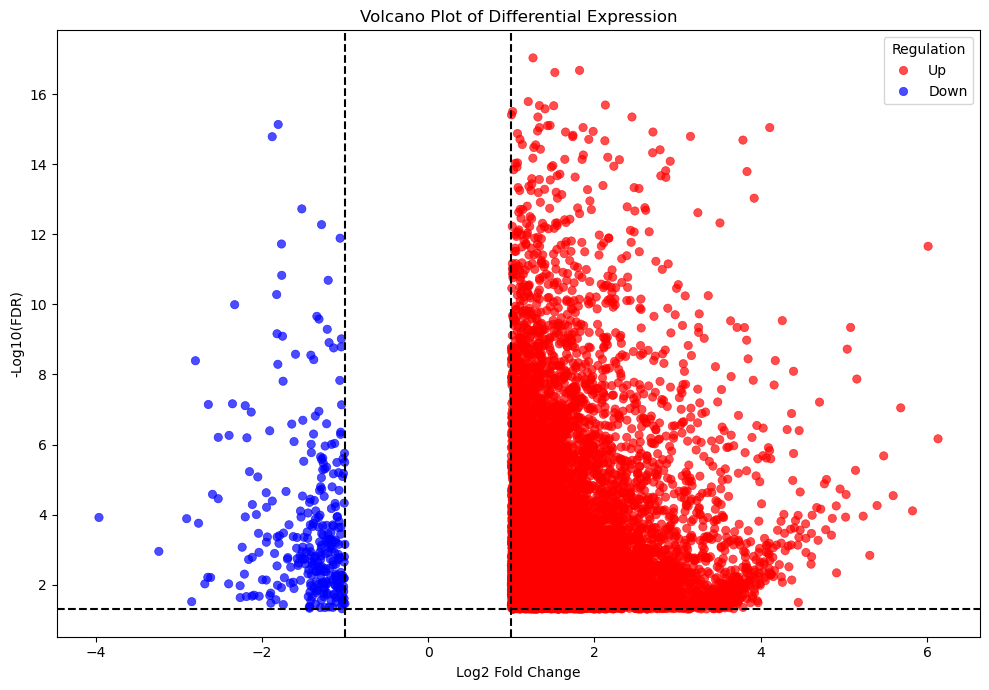

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set working folder
folder = r"C:\Users\Neg\TCGA_GC_project"

# Load the filtered DEG results
deg_path = os.path.join(folder, "DEGs_MWU_filtered.csv")
deg_df = pd.read_csv(deg_path)

# Classify up/downregulated
deg_df['Regulation'] = deg_df['log2FC'].apply(lambda x: 'Up' if x >= 1 else ('Down' if x <= -1 else 'None'))

# Count DEGs
up_count = (deg_df['Regulation'] == 'Up').sum()
down_count = (deg_df['Regulation'] == 'Down').sum()

print(f"✅ Upregulated genes: {up_count}")
print(f"✅ Downregulated genes: {down_count}")

# Save summary
deg_summary_path = os.path.join(folder, "DEG_summary.txt")
with open(deg_summary_path, "w") as f:
    f.write(f"Upregulated genes: {up_count}\n")
    f.write(f"Downregulated genes: {down_count}\n")

# Volcano Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=deg_df,
    x='log2FC',
    y=-np.log10(deg_df['FDR']),
    hue='Regulation',
    palette={'Up': 'red', 'Down': 'blue', 'None': 'grey'},
    edgecolor=None,
    alpha=0.7
)

plt.axhline(-np.log10(0.05), linestyle='--', color='black')
plt.axvline(1, linestyle='--', color='black')
plt.axvline(-1, linestyle='--', color='black')
plt.title("Volcano Plot of Differential Expression")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(FDR)")
plt.legend(title="Regulation")
plt.tight_layout()

# Save plot
plot_path = os.path.join(folder, "volcano_plot_DEGs.png")
plt.savefig(plot_path, dpi=300)
plt.show()


In [13]:
import pandas as pd

# Load the filtered DEGs file
file_path = "C:/Users/Neg/TCGA_GC_project/DEGs_MWU_filtered.csv"
degs_df = pd.read_csv(file_path)

# Count total DEGs
total_degs = degs_df.shape[0]

# Count upregulated (log2FC >= 1)
upregulated = degs_df[degs_df['log2FC'] >= 1].shape[0]

# Count downregulated (log2FC <= -1)
downregulated = degs_df[degs_df['log2FC'] <= -1].shape[0]

print(f"Total DEGs: {total_degs}")
print(f"Upregulated genes: {upregulated}")
print(f"Downregulated genes: {downregulated}")


Total DEGs: 9896
Upregulated genes: 9592
Downregulated genes: 304


In [14]:
import pandas as pd

# Load the DEGs file
file_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
df = pd.read_csv(file_path)

# Compute absolute log2FC for sorting
df['abs_log2FC'] = df['log2FC'].abs()

# Select top 100 upregulated (log2FC > 0)
upregulated_top100 = df[df['log2FC'] > 0].nlargest(100, 'abs_log2FC')

# Select top 100 downregulated (log2FC < 0)
downregulated_top100 = df[df['log2FC'] < 0].nlargest(100, 'abs_log2FC')

# Merge them
top200_genes = pd.concat([upregulated_top100, downregulated_top100])

# Save to file
output_path = r"C:\Users\Neg\TCGA_GC_project\Top200_DEGs_by_absLog2FC.csv"
top200_genes.to_csv(output_path, index=False)

print("✅ Top 200 DEGs saved to:", output_path)


✅ Top 200 DEGs saved to: C:\Users\Neg\TCGA_GC_project\Top200_DEGs_by_absLog2FC.csv


In [15]:
import pandas as pd
import numpy as np

# Load files
expr_path = r"C:\Users\Neg\TCGA_GC_project\expression_matched.csv"
labels_path = r"C:\Users\Neg\TCGA_GC_project\sample_labels.csv"
mwu_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"

expr_df = pd.read_csv(expr_path, index_col=0)
sample_labels = pd.read_csv(labels_path, index_col=0).squeeze()
mwu_df = pd.read_csv(mwu_path)

# Separate tumor and normal samples
tumor_samples = sample_labels[sample_labels == "Tumor"].index
normal_samples = sample_labels[sample_labels == "Normal"].index

# Calculate log2FC with pseudocount to avoid division by zero
pseudocount = 1e-6
mean_tumor = expr_df[tumor_samples].mean(axis=1) + pseudocount
mean_normal = expr_df[normal_samples].mean(axis=1) + pseudocount
log2fc = np.log2(mean_tumor / mean_normal)

# Convert to DataFrame and reset index to merge by Gene symbol
log2fc_df = log2fc.reset_index()
log2fc_df.columns = ['Gene', 'log2FC']
log2fc_df['abs_log2FC'] = log2fc_df['log2FC'].abs()

# Merge with MWU results by 'Gene'
merged_df = pd.merge(mwu_df, log2fc_df, on='Gene', how='left')

# Save the updated file
output_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered_log2fc.csv"
merged_df.to_csv(output_path, index=False)
print(f"✅ Updated DEGs with log2FC saved to: {output_path}")


✅ Updated DEGs with log2FC saved to: C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered_log2fc.csv


In [16]:
import pandas as pd

# Load the updated DEGs file
file_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered_log2fc.csv"
df = pd.read_csv(file_path)

# Filter upregulated genes (log2FC > 0)
top_up = df[df['log2FC_y'] > 0].sort_values(by='abs_log2FC', ascending=False).head(100)

# Filter downregulated genes (log2FC < 0)
top_down = df[df['log2FC_y'] < 0].sort_values(by='abs_log2FC', ascending=False).head(100)

# Combine and save
top_combined = pd.concat([top_up, top_down]).reset_index(drop=True)
output_path = r"C:\Users\Neg\TCGA_GC_project\Top200_DEGs_for_STRING.csv"
top_combined.to_csv(output_path, index=False)

print(f"✅ Top 200 DEGs saved to: {output_path}")


✅ Top 200 DEGs saved to: C:\Users\Neg\TCGA_GC_project\Top200_DEGs_for_STRING.csv


In [17]:
import pandas as pd

# Load expression matrix
expr_path = r"C:\Users\Neg\TCGA_GC_project\expression_matched.csv"
expr_df = pd.read_csv(expr_path, index_col=0)

# Load DEGs
degs_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
degs_df = pd.read_csv(degs_path)

# Fix column names (in case of inf, etc.)
if 'log2FC_y' in degs_df.columns:
    degs_df['abs_log2FC'] = degs_df['log2FC_y'].abs()
elif 'log2FC' in degs_df.columns:
    degs_df['abs_log2FC'] = degs_df['log2FC'].abs()
else:
    raise ValueError("No valid log2FC column found in the DEGs file.")

# Take top 10 DEGs by absolute log2FC
top_genes = degs_df.sort_values(by='abs_log2FC', ascending=False).head(10)['Gene'].tolist()

# Extract sample group labels from TCGA barcode
sample_types = expr_df.columns.str.slice(13, 15)
sample_labels = sample_types.map({'01': 'Tumor', '11': 'Normal'})

# Split tumor and normal sample columns
tumor_samples = expr_df.columns[sample_labels == 'Tumor']
normal_samples = expr_df.columns[sample_labels == 'Normal']

# Extract and summarize expression
top_expr = expr_df.loc[top_genes]
tumor_avg = top_expr[tumor_samples].mean(axis=1)
normal_avg = top_expr[normal_samples].mean(axis=1)

# Summary table
summary_df = pd.DataFrame({
    'Gene': top_expr.index,
    'Avg_Tumor_Expression': tumor_avg.values,
    'Avg_Normal_Expression': normal_avg.values
})

# Save the result
output_path = r"C:\Users\Neg\TCGA_GC_project\top_DEGs_expression_check.csv"
summary_df.to_csv(output_path, index=False)

print("✅ Expression summary saved to:", output_path)
summary_df


✅ Expression summary saved to: C:\Users\Neg\TCGA_GC_project\top_DEGs_expression_check.csv


,Gene,Avg_Tumor_Expression,Avg_Normal_Expression
0,ENSG00000243154.1,0.215049,0.0
1,ENSG00000267303.1,0.202654,0.0
2,ENSG00000185982.7,0.218701,0.0
3,ENSG00000231601.1,0.260772,0.0
4,ENSG00000267471.1,0.252246,0.0
5,ENSG00000231491.2,0.242768,0.0
6,ENSG00000267564.1,0.192267,0.0
7,ENSG00000267599.1,0.233874,0.0
8,ENSG00000231248.3,0.163863,0.0
9,ENSG00000231189.1,0.204800,0.0


In [18]:
import pandas as pd

deg_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
df = pd.read_csv(deg_path)
print("Available columns:")
print(df.columns.tolist())


Available columns:
['Gene', 'log2FC', 'p_value', 'FDR']


In [19]:
import pandas as pd

# Load expression matrix
expr_path = r"C:\Users\Neg\TCGA_GC_project\expression_matched.csv"
labels_path = r"C:\Users\Neg\TCGA_GC_project\sample_labels.csv"

expr_df = pd.read_csv(expr_path, index_col=0)
sample_labels = pd.read_csv(labels_path, index_col=0).squeeze()

# Sanity check
print("✅ Expression shape:", expr_df.shape)
print("✅ Labels shape:", sample_labels.shape)

# Separate tumor and normal samples
tumor_samples = sample_labels[sample_labels == 'Tumor'].index
normal_samples = sample_labels[sample_labels == 'Normal'].index

# Calculate average expression
avg_tumor_expr = expr_df[tumor_samples].mean(axis=1)
avg_normal_expr = expr_df[normal_samples].mean(axis=1)

# Combine into a new DataFrame
avg_expr_df = pd.DataFrame({
    'Gene': expr_df.index,
    'Avg_Tumor_Expression': avg_tumor_expr.values,
    'Avg_Normal_Expression': avg_normal_expr.values
})

# Save the output
avg_expr_df.to_csv(r"C:\Users\Neg\TCGA_GC_project\Avg_Tumor_Normal_Expression.csv", index=False)

print("✅ Average expression file saved as Avg_Tumor_Normal_Expression.csv")


✅ Expression shape: (56678, 448)
✅ Labels shape: (448,)
✅ Average expression file saved as Avg_Tumor_Normal_Expression.csv


In [20]:
import pandas as pd

# Load files
deg_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
avg_expr_path = r"C:\Users\Neg\TCGA_GC_project\Avg_Tumor_Normal_Expression.csv"

deg_df = pd.read_csv(deg_path)
avg_df = pd.read_csv(avg_expr_path)

# Strip spaces from column names just in case
deg_df.columns = deg_df.columns.str.strip()
avg_df.columns = avg_df.columns.str.strip()

# Merge average expression into DEGs
merged_df = pd.merge(deg_df, avg_df, on="Gene")

# Filter: keep only genes with Avg_Tumor_Expression >= 1 and Avg_Normal_Expression >= 1
filtered_df = merged_df[
    (merged_df["Avg_Tumor_Expression"] >= 1) &
    (merged_df["Avg_Normal_Expression"] >= 1)
].copy()

# Sort by log2FC to get top upregulated and downregulated
top_up = filtered_df.sort_values(by="log2FC", ascending=False).head(100)
top_down = filtered_df.sort_values(by="log2FC", ascending=True).head(100)

# Combine for final high-confidence DEGs
top_combined = pd.concat([top_up, top_down]).reset_index(drop=True)

# Save
output_path = r"C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs.csv"
top_combined.to_csv(output_path, index=False)

print("✅ Final DEG list saved:", output_path)
print("🧬 Total genes selected:", top_combined.shape[0])


✅ Final DEG list saved: C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs.csv
🧬 Total genes selected: 200


In [21]:
import pandas as pd
from mygene import MyGeneInfo

# Load the file with Ensembl IDs
file_path = r"C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs.csv"
df = pd.read_csv(file_path)

# Remove version suffix from Ensembl IDs
df['Ensembl_ID'] = df['Gene'].str.split('.').str[0]

# Query mygene to convert Ensembl IDs to gene symbols
mg = MyGeneInfo()
query_results = mg.querymany(df['Ensembl_ID'].tolist(), scopes='ensembl.gene', fields='symbol', species='human')

# Convert to DataFrame
mapping_df = pd.DataFrame(query_results)[['query', 'symbol']].rename(columns={'query': 'Ensembl_ID', 'symbol': 'Gene_Symbol'})

# Merge with original data
df_merged = pd.merge(df, mapping_df, on='Ensembl_ID', how='left')

# Save to Excel
output_path = r"C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs_with_Symbols.xlsx"
df_merged.to_excel(output_path, index=False)

print("✅ File saved at:", output_path)


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
5 input query terms found no hit:	['ENSG00000227925', 'ENSG00000275216', 'ENSG00000243944', 'ENSG00000224287', 'ENSG00000237838']


✅ File saved at: C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs_with_Symbols.xlsx


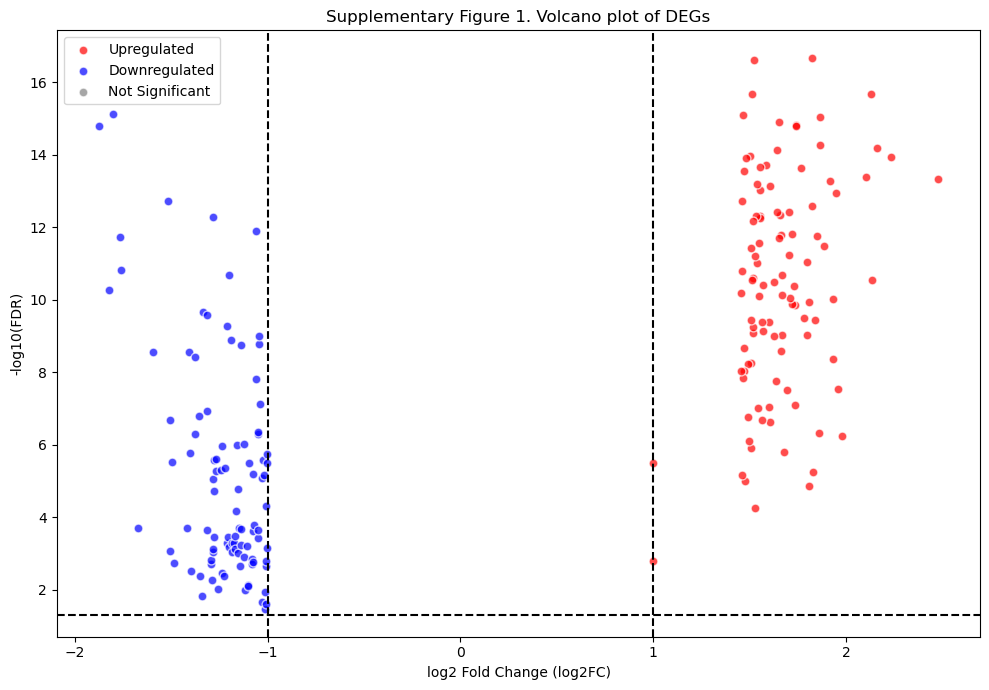

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# File paths
file_path = r"C:\Users\Neg\TCGA_GC_project\Top200_HighConfidence_DEGs_with_Symbols.xlsx"
output_dir = r"C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "Supplementary_Figure1_VolcanoPlot.png")

# Load data
df = pd.read_excel(file_path)

# Compute -log10(FDR)
df['-log10(FDR)'] = -np.log10(df['FDR'])

# Label genes
df['Regulation'] = 'Not Significant'
df.loc[(df['log2FC'] >= 1) & (df['FDR'] < 0.05), 'Regulation'] = 'Upregulated'
df.loc[(df['log2FC'] <= -1) & (df['FDR'] < 0.05), 'Regulation'] = 'Downregulated'

# Plot
plt.figure(figsize=(10, 7))
colors = {'Upregulated': 'red', 'Downregulated': 'blue', 'Not Significant': 'grey'}
for label, color in colors.items():
    subset = df[df['Regulation'] == label]
    plt.scatter(subset['log2FC'], subset['-log10(FDR)'], c=color, label=label, alpha=0.7, s=40, edgecolors='w')

plt.axvline(x=1, linestyle='--', color='black')
plt.axvline(x=-1, linestyle='--', color='black')
plt.axhline(y=-np.log10(0.05), linestyle='--', color='black')

plt.xlabel("log2 Fold Change (log2FC)")
plt.ylabel("-log10(FDR)")
plt.title("Supplementary Figure 1. Volcano plot of DEGs")
plt.legend()
plt.tight_layout()

# Save plot
plt.savefig(plot_path, dpi=300)
plt.show()


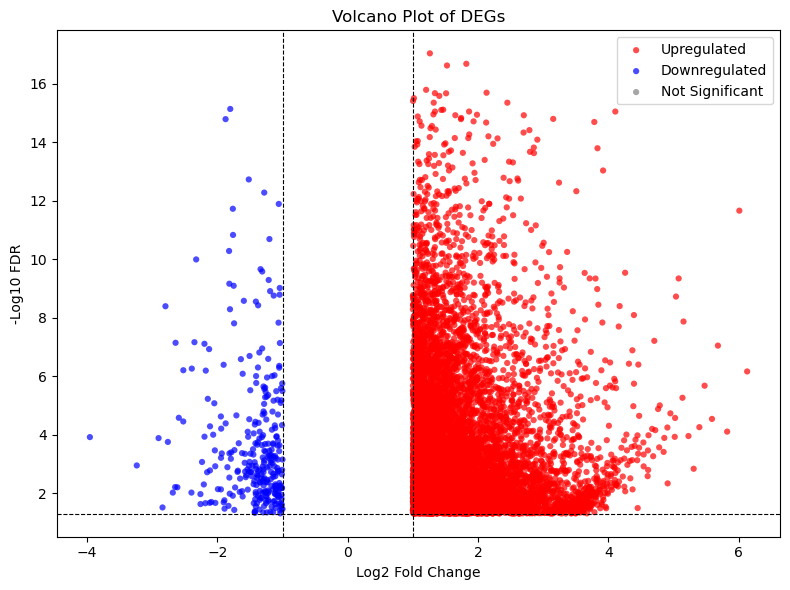

✅ Volcano plot saved to C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission\Supplementary_Figure1_VolcanoPlot_Full_DEGs.png


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load DEGs_MWU_filtered.csv
deg_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
degs = pd.read_csv(deg_path)

# Check and clean column names
degs.columns = degs.columns.str.strip()

# Thresholds
log2fc_threshold = 1
fdr_threshold = 0.05

# Assign categories
degs['Category'] = 'Not Significant'
degs.loc[(degs['log2FC'] >= log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Upregulated'
degs.loc[(degs['log2FC'] <= -log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Downregulated'

# Prepare colors
colors = {
    'Upregulated': 'red',
    'Downregulated': 'blue',
    'Not Significant': 'grey'
}

# Create output folder if doesn't exist
output_folder = r"C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission"
os.makedirs(output_folder, exist_ok=True)

# Create volcano plot
plt.figure(figsize=(8, 6))
for category, color in colors.items():
    subset = degs[degs['Category'] == category]
    plt.scatter(subset['log2FC'], -np.log10(subset['FDR']), c=color, label=category, alpha=0.7, edgecolors='none', s=20)

# Plot settings
plt.axhline(-np.log10(fdr_threshold), color='black', linestyle='--', linewidth=0.8)
plt.axvline(log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
plt.axvline(-log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 FDR')
plt.title('Volcano Plot of DEGs')
plt.legend()
plt.tight_layout()

# Save plot
plot_path = os.path.join(output_folder, "Supplementary_Figure1_VolcanoPlot_Full_DEGs.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Volcano plot saved to {plot_path}")


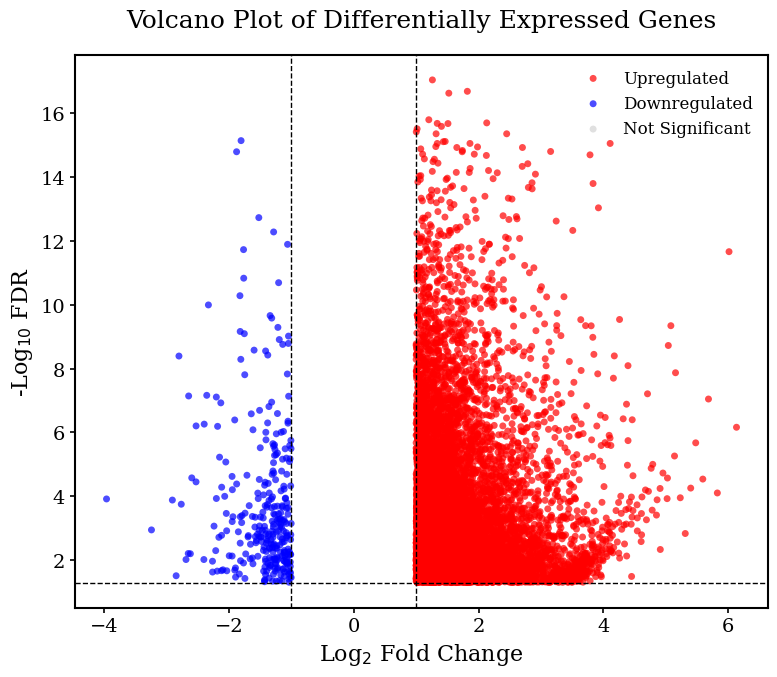

✅ Volcano plot (high-quality) saved to C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission\Supplementary_Figure1_VolcanoPlot_Full_DEGs_NatureStyle.png


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load DEGs_MWU_filtered.csv
deg_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
degs = pd.read_csv(deg_path)

# Clean column names
degs.columns = degs.columns.str.strip()

# Thresholds
log2fc_threshold = 1
fdr_threshold = 0.05

# Assign categories
degs['Category'] = 'Not Significant'
degs.loc[(degs['log2FC'] >= log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Upregulated'
degs.loc[(degs['log2FC'] <= -log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Downregulated'

# Prepare colors
colors = {
    'Upregulated': 'red',
    'Downregulated': 'blue',
    'Not Significant': 'lightgrey'
}

# Output folder
output_folder = r"C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission"
os.makedirs(output_folder, exist_ok=True)

# Set matplotlib style for publication-quality
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'legend.fontsize': 12
})

# Create volcano plot
plt.figure(figsize=(8, 7))
for category, color in colors.items():
    subset = degs[degs['Category'] == category]
    plt.scatter(subset['log2FC'], -np.log10(subset['FDR']), c=color, label=category, alpha=0.7, edgecolors='none', s=25)

# Threshold lines
plt.axhline(-np.log10(fdr_threshold), color='black', linestyle='--', linewidth=1)
plt.axvline(log2fc_threshold, color='black', linestyle='--', linewidth=1)
plt.axvline(-log2fc_threshold, color='black', linestyle='--', linewidth=1)

# Axis labels
plt.xlabel('Log$_2$ Fold Change', fontsize=16)
plt.ylabel('-Log$_{10}$ FDR', fontsize=16)

# Title
plt.title('Volcano Plot of Differentially Expressed Genes', fontsize=18, pad=20)

# Legend
plt.legend(frameon=False)

# Tight layout
plt.tight_layout()

# Save plot (high resolution)
plot_path = os.path.join(output_folder, "Supplementary_Figure1_VolcanoPlot_Full_DEGs_NatureStyle.png")
plt.savefig(plot_path, dpi=600)
plt.show()

print(f"✅ Volcano plot (high-quality) saved to {plot_path}")


C:\Users\Neg\anaconda3\Lib\site-packages\matplotlib\transforms.py:354: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite va

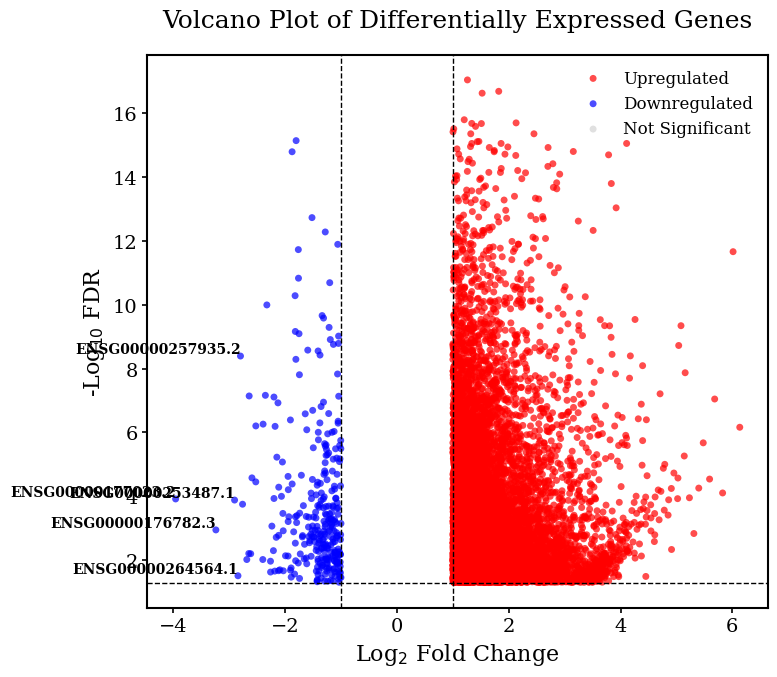

✅ Volcano plot with gene labels saved to C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission\Supplementary_Figure1_VolcanoPlot_Full_DEGs_WithLabels.png


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load DEGs
deg_path = r"C:\Users\Neg\TCGA_GC_project\DEGs_MWU_filtered.csv"
degs = pd.read_csv(deg_path)

# Clean column names
degs.columns = degs.columns.str.strip()

# Thresholds
log2fc_threshold = 1
fdr_threshold = 0.05

# Assign categories
degs['Category'] = 'Not Significant'
degs.loc[(degs['log2FC'] >= log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Upregulated'
degs.loc[(degs['log2FC'] <= -log2fc_threshold) & (degs['FDR'] < fdr_threshold), 'Category'] = 'Downregulated'

# Prepare colors
colors = {
    'Upregulated': 'red',
    'Downregulated': 'blue',
    'Not Significant': 'lightgrey'
}

# Output folder
output_folder = r"C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission"
os.makedirs(output_folder, exist_ok=True)

# Set matplotlib style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'legend.fontsize': 12
})

# Create volcano plot
plt.figure(figsize=(8, 7))
for category, color in colors.items():
    subset = degs[degs['Category'] == category]
    plt.scatter(subset['log2FC'], -np.log10(subset['FDR']), c=color, label=category, alpha=0.7, edgecolors='none', s=25)

# Threshold lines
plt.axhline(-np.log10(fdr_threshold), color='black', linestyle='--', linewidth=1)
plt.axvline(log2fc_threshold, color='black', linestyle='--', linewidth=1)
plt.axvline(-log2fc_threshold, color='black', linestyle='--', linewidth=1)

# Label top genes
# Top 5 upregulated (largest positive log2FC) and top 5 downregulated (smallest negative log2FC)
top_up = degs[(degs['Category'] == 'Upregulated')].nlargest(5, 'log2FC')
top_down = degs[(degs['Category'] == 'Downregulated')].nsmallest(5, 'log2FC')

for _, row in pd.concat([top_up, top_down]).iterrows():
    plt.text(row['log2FC'], -np.log10(row['FDR']), row['Gene'], 
             fontsize=10, ha='right' if row['log2FC'] < 0 else 'left', 
             va='bottom', fontweight='bold')

# Axis labels
plt.xlabel('Log$_2$ Fold Change', fontsize=16)
plt.ylabel('-Log$_{10}$ FDR', fontsize=16)

# Title
plt.title('Volcano Plot of Differentially Expressed Genes', fontsize=18, pad=20)

# Legend
plt.legend(frameon=False)

# Tight layout
plt.tight_layout()

# Save plot
plot_path = os.path.join(output_folder, "Supplementary_Figure1_VolcanoPlot_Full_DEGs_WithLabels.png")
plt.savefig(plot_path, dpi=600)
plt.show()

print(f"✅ Volcano plot with gene labels saved to {plot_path}")


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
base_dir = r"C:\Users\Neg\TCGA_GC_project"
deg_file = os.path.join(base_dir, "Top200_HighConfidence_DEGs_with_Symbols.xlsx")
output_dir = os.path.join(base_dir, "Supplementary_files_4_manuscript_submission")
os.makedirs(output_dir, exist_ok=True)

# Load the DEGs data
deg_df = pd.read_excel(deg_file)

# Assume we have the following columns: ['Gene_Symbol', 'log2FC']
# Create a new column indicating regulation direction
deg_df['Regulation'] = deg_df['log2FC'].apply(lambda x: 'Upregulated' if x > 0 else 'Downregulated')

# --------------------------
# Supplementary Figure 2: Violin Plot for Expression Distribution
# --------------------------
plt.figure(figsize=(8, 6))
sns.violinplot(x='Regulation', y='log2FC', data=deg_df, inner='box', palette={'Upregulated': 'red', 'Downregulated': 'blue'})
plt.title('Supplementary Figure 2: Expression Distribution of Top DEGs')
plt.xlabel('')
plt.ylabel('log2 Fold Change (log2FC)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Supplementary_Figure_2_ViolinPlot.png"))
plt.close()

# --------------------------
# Supplementary Figure 3: Bar Plot for DEG Counts
# --------------------------
deg_counts = {'Upregulated': (deg_df['Regulation'] == 'Upregulated').sum(),
              'Downregulated': (deg_df['Regulation'] == 'Downregulated').sum()}
deg_counts_df = pd.DataFrame.from_dict(deg_counts, orient='index', columns=['Count']).reset_index()
deg_counts_df.rename(columns={'index': 'Regulation'}, inplace=True)

plt.figure(figsize=(6, 6))
sns.barplot(x='Regulation', y='Count', data=deg_counts_df, palette={'Upregulated': 'red', 'Downregulated': 'blue'})
plt.title('Supplementary Figure 3: DEG Counts')
plt.ylabel('Number of Genes')
plt.xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Supplementary_Figure_3_BarPlot.png"))
plt.close()

print("✅ Plots generated and saved to:", output_dir)


C:\Users\Neg\AppData\Local\Temp\ipykernel_27136\3618910920.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Regulation', y='log2FC', data=deg_df, inner='box', palette={'Upregulated': 'red', 'Downregulated': 'blue'})
C:\Users\Neg\AppData\Local\Temp\ipykernel_27136\3618910920.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regulation', y='Count', data=deg_counts_df, palette={'Upregulated': 'red', 'Downregulated': 'blue'})


✅ Plots generated and saved to: C:\Users\Neg\TCGA_GC_project\Supplementary_files_4_manuscript_submission
